# Notebook 03 — Feature Engineering
**Predicción de Diagnóstico de Cáncer · UAX 2025/2026**

Sección cubierta: **Sección 3 — Ingeniería de Features**

Construimos variables nuevas que los modelos no pueden descubrir solos a partir
de las columnas raw. Cada feature se valida antes de incluirla.

Contenido:
- 3.1 Aggregaciones de riesgo: `n_mutaciones`, `n_comorbilidades`
- 3.2 Carga mutacional ponderada por pesos del Oracle
- 3.3 Umbrales bioquímicos clínicos (alineados con el modelo generativo)
- 3.4 Encoding ordinal de `actividad_fisica`
- 3.5 Discretización de edad en franjas de riesgo
- 3.6 Interacciones clínicas de alto valor
- 3.7 Validación de cada feature construida
- 3.8 Resumen visual: ranking de señal de todas las features

**Carga:** `data/processed/df_master.parquet`
**Genera:** `data/processed/df_engineered.parquet`

---
## Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy import stats

warnings.filterwarnings('ignore')

ROOT     = os.path.abspath('..')
OUT_FIGS = os.path.join(ROOT, 'outputs', 'figures')
os.makedirs(OUT_FIGS, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

df = pd.read_parquet(os.path.join(ROOT, 'data', 'processed', 'df_master.parquet'))
print(f"Dataset cargado: {df.shape[0]:,} pacientes x {df.shape[1]} variables")

# Columnas base para referencia
BASELINE_COLS = [c for c in df.columns if c not in ['paciente_id', 'cancer']]
print(f"Variables base (sin target ni ID): {len(BASELINE_COLS)}")

Dataset cargado: 50,001 pacientes x 33 variables
Variables base (sin target ni ID): 31


---
## Helper de validación

Función que usaremos para evaluar cada feature nueva: mide su correlación con el
target, la compara con sus componentes y confirma que no hay leakage.

In [2]:
def evaluar_feature(df, nombre, componentes=None):
    """Calcula chi2/r con el target y compara con componentes originales."""
    feat = df[nombre]
    target = df['cancer']

    if feat.nunique() <= 10:
        ct = pd.crosstab(feat, target)
        chi2, p, _, _ = stats.chi2_contingency(ct, correction=False)
        signal = f"chi2={chi2:.1f}"
        signal_val = chi2
    else:
        g0 = feat[target == 0]
        g1 = feat[target == 1]
        stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
        r = abs(1 - (2 * stat) / (len(g0) * len(g1)))
        signal = f"r={r:.4f}"
        signal_val = r

    mejora = ""
    if componentes:
        comp_signals = []
        for c in componentes:
            if df[c].nunique() <= 10:
                ct2 = pd.crosstab(df[c], target)
                chi2_c, _, _, _ = stats.chi2_contingency(ct2, correction=False)
                comp_signals.append(chi2_c)
            else:
                g0c = df.loc[target==0, c]
                g1c = df.loc[target==1, c]
                stat_c, _ = stats.mannwhitneyu(g0c, g1c, alternative='two-sided')
                comp_signals.append(abs(1 - (2*stat_c)/(len(g0c)*len(g1c))))
        mejor_comp = max(comp_signals)
        if signal_val > mejor_comp:
            mejora = f"  MEJORA sobre componentes (max_comp={mejor_comp:.1f})"
        else:
            mejora = f"  No mejora sobre componentes (max_comp={mejor_comp:.1f})"

    print(f"  {nombre:<30} {signal:<20} p={p:.2e}{mejora}")
    return signal_val

---
## 3.1 Agregaciones de riesgo

La acumulación de mutaciones y comorbilidades actúa como *switch* de riesgo:
a partir de cierto número la probabilidad de cáncer se dispara.
Estas sumas aritméticas se calculan sobre el dataset completo **antes** del split
— no aprenden del train, no hay riesgo de leakage.

Validacion de features de agregacion:
  n_mutaciones                   chi2=5400.2          p=0.00e+00  MEJORA sobre componentes (max_comp=2388.7)
  n_comorbilidades               chi2=1793.3          p=0.00e+00  No mejora sobre componentes (max_comp=1953.9)


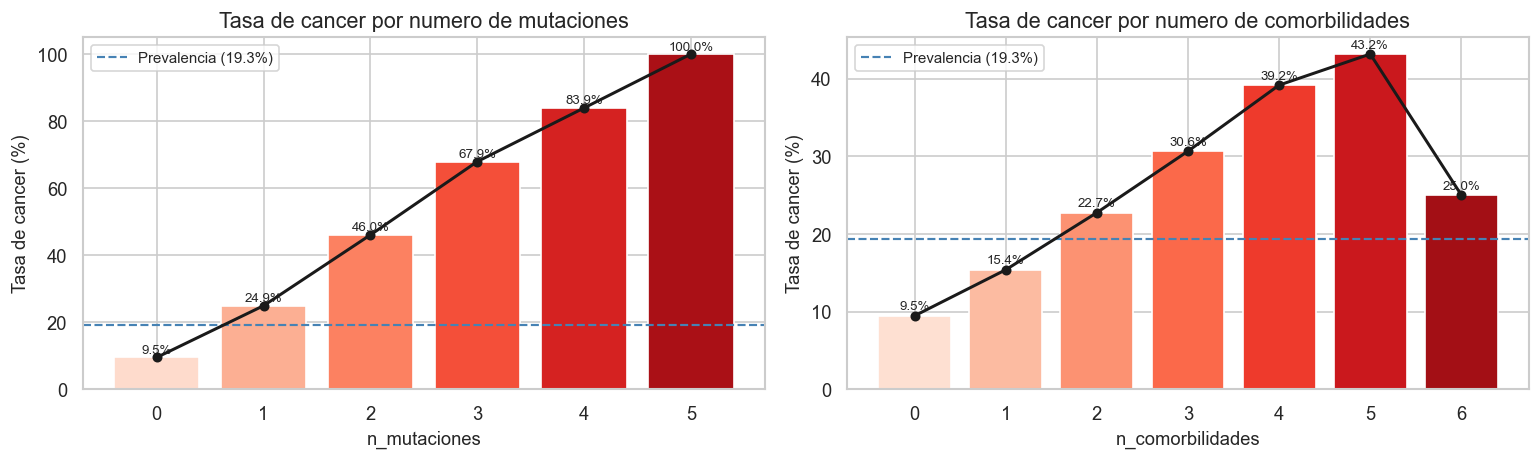

In [3]:
# mut_ALK excluida: chi2=0.0, p=0.93 (señal estadísticamente nula)
MUT_COLS    = ['mut_BRCA1','mut_TP53','mut_EGFR','mut_KRAS','mut_PIK3CA','mut_BRAF']
COMORB_COLS = ['diabetes','hipertension','obesidad','enfermedad_cardiaca','asma','epoc']

df['n_mutaciones']     = df[MUT_COLS].sum(axis=1)
df['n_comorbilidades'] = df[COMORB_COLS].sum(axis=1)

print("Validacion de features de agregacion:")
evaluar_feature(df, 'n_mutaciones',    componentes=MUT_COLS)
evaluar_feature(df, 'n_comorbilidades', componentes=COMORB_COLS)

# Visualizacion conjunta
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
prev = df['cancer'].mean()

for ax, feat, title in zip(axes,
    ['n_mutaciones', 'n_comorbilidades'],
    ['Tasa de cancer por numero de mutaciones',
     'Tasa de cancer por numero de comorbilidades']):
    tasa = df.groupby(feat)['cancer'].agg(tasa='mean', n='count').reset_index()
    palette = sns.color_palette('Reds', len(tasa))
    bars = ax.bar(tasa[feat], tasa['tasa']*100, color=palette, edgecolor='white')
    ax.plot(tasa[feat], tasa['tasa']*100, 'o-k', linewidth=1.8, markersize=5, zorder=5)
    ax.axhline(prev*100, color='steelblue', linestyle='--', linewidth=1.3,
               label=f'Prevalencia ({100*prev:.1f}%)')
    ax.set_xlabel(feat)
    ax.set_ylabel('Tasa de cancer (%)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    for bar, (_, row) in zip(bars, tasa.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{row["tasa"]*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '08_aggregation_features.png'), bbox_inches='tight')
plt.show()

---
## 3.2 Carga mutacional ponderada

En lugar de tratar todas las mutaciones igual, las pesamos por su importancia
en el modelo generativo (fuente: `metadata.md`).

```
weighted_mutation_burden = 2.0·BRCA1 + 1.8·TP53 + 1.4·KRAS + 1.0·EGFR + 0.8·PIK3CA + 0.6·BRAF
```

Esto captura que tener BRCA1 no es lo mismo que tener BRAF — diferencia que
`n_mutaciones` ignora por completo.

Validacion de carga mutacional ponderada:
  weighted_mut_burden            r=0.4377             p=0.00e+00  No mejora sobre componentes (max_comp=2388.7)

Distribucion del weighted_mut_burden:
count    50001.000
mean         0.771
std          1.015
min          0.000
25%          0.000
50%          0.000
75%          1.400
max          6.200
Name: weighted_mut_burden, dtype: float64


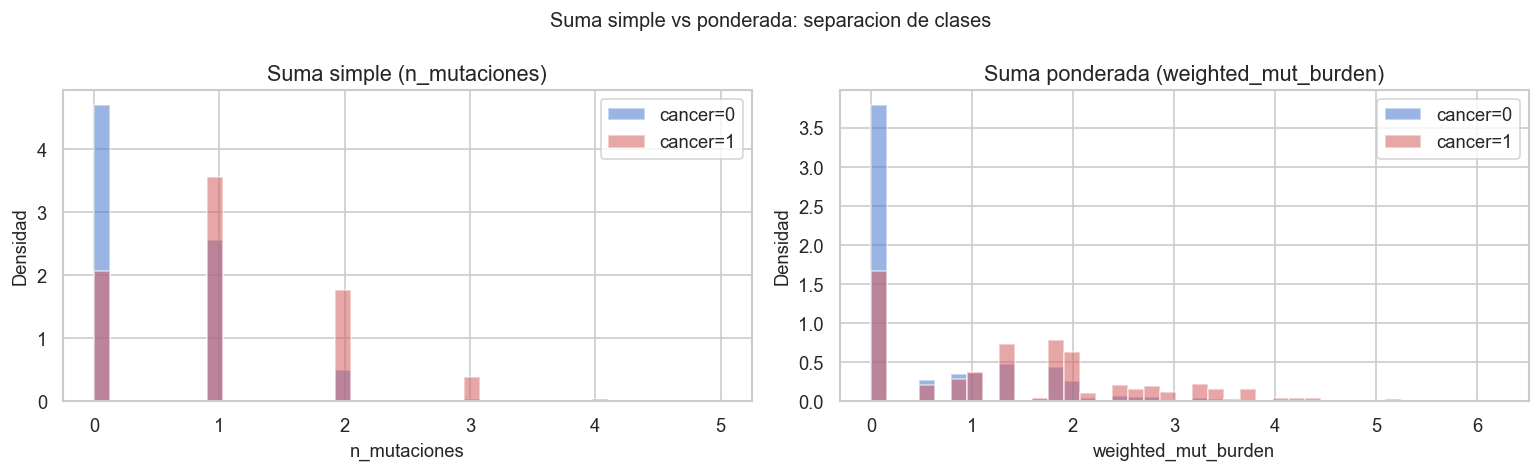

In [4]:
# Pesos directamente del modelo generativo documentado en metadata.md
ORACLE_MUT_WEIGHTS = {
    'mut_BRCA1':  2.0,
    'mut_TP53':   1.8,
    'mut_KRAS':   1.4,
    'mut_EGFR':   1.0,
    'mut_PIK3CA': 0.8,
    'mut_BRAF':   0.6,
}

df['weighted_mut_burden'] = sum(
    w * df[gene] for gene, w in ORACLE_MUT_WEIGHTS.items()
)

print("Validacion de carga mutacional ponderada:")
evaluar_feature(df, 'weighted_mut_burden', componentes=list(ORACLE_MUT_WEIGHTS.keys()))
print()
print("Distribucion del weighted_mut_burden:")
print(df['weighted_mut_burden'].describe().round(3))

# Comparacion: n_mutaciones vs weighted_mut_burden
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, feat, title in zip(axes,
    ['n_mutaciones', 'weighted_mut_burden'],
    ['Suma simple (n_mutaciones)', 'Suma ponderada (weighted_mut_burden)']):
    g0 = df.loc[df['cancer']==0, feat]
    g1 = df.loc[df['cancer']==1, feat]
    bins = np.linspace(df[feat].min(), df[feat].max(), 40)
    ax.hist(g0, bins=bins, alpha=0.55, density=True, color='#4878CF', label='cancer=0')
    ax.hist(g1, bins=bins, alpha=0.55, density=True, color='#D65F5F', label='cancer=1')
    ax.set_xlabel(feat)
    ax.set_ylabel('Densidad')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Suma simple vs ponderada: separacion de clases', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '09_mutation_burden_comparison.png'), bbox_inches='tight')
plt.show()

---
## 3.3 Umbrales bioquímicos clínicos

El modelo generativo usa tres umbrales clínicos documentados en el metadata:
- `glucosa > 130 mg/dL` — criterio de diabetes mal controlada
- `hemoglobina < 11 g/dL` — umbral de anemia moderada-severa
- `leucocitos > 10 ×10³/µL` — leucocitosis (inflamación crónica)

Creamos variables binarias explícitas. Los modelos de árbol las descubrirían
solos, pero para la MLP y la regresión logística tenerlas explícitas
mejora la captura de estas no-linealidades.

In [5]:
df['glucosa_alta']      = (df['glucosa']     > 130).astype(int)
df['hemoglobina_baja']  = (df['hemoglobina'] < 11).astype(int)
df['leucocitos_alto']   = (df['leucocitos']  > 10).astype(int)

print("Validacion de umbrales bioquimicos:")
for feat, comp in [
    ('glucosa_alta',     ['glucosa']),
    ('hemoglobina_baja', ['hemoglobina']),
    ('leucocitos_alto',  ['leucocitos']),
]:
    evaluar_feature(df, feat, componentes=comp)

# Prevalencias en cada grupo
print()
umbral_stats = []
for feat, label0, label1 in [
    ('glucosa_alta',    'glucosa <= 130', 'glucosa > 130'),
    ('hemoglobina_baja','hemoglobina >= 11','hemoglobina < 11'),
    ('leucocitos_alto', 'leucocitos <= 10', 'leucocitos > 10'),
]:
    t0 = df.loc[df[feat]==0, 'cancer'].mean()
    t1 = df.loc[df[feat]==1, 'cancer'].mean()
    n0 = (df[feat]==0).sum()
    n1 = (df[feat]==1).sum()
    print(f"  {feat}: {label0} -> {100*t0:.1f}% cancer (n={n0:,}) | "
          f"{label1} -> {100*t1:.1f}% cancer (n={n1:,})")

Validacion de umbrales bioquimicos:
  glucosa_alta                   chi2=1546.2          p=0.00e+00  MEJORA sobre componentes (max_comp=0.2)
  hemoglobina_baja               chi2=370.1           p=1.79e-82  MEJORA sobre componentes (max_comp=0.1)
  leucocitos_alto                chi2=575.0           p=4.52e-127  MEJORA sobre componentes (max_comp=0.1)

  glucosa_alta: glucosa <= 130 -> 17.3% cancer (n=46,126) | glucosa > 130 -> 43.2% cancer (n=3,875)
  hemoglobina_baja: hemoglobina >= 11 -> 18.7% cancer (n=48,570) | hemoglobina < 11 -> 39.1% cancer (n=1,431)
  leucocitos_alto: leucocitos <= 10 -> 18.2% cancer (n=46,842) | leucocitos > 10 -> 35.6% cancer (n=3,159)


---
## 3.4 Encoding ordinal de `actividad_fisica`

La relación con el target es monotónica: Alta < Moderada < Baja en tasa de cáncer.
Esto justifica codificación ordinal en lugar de one-hot.

In [6]:
tasa_act = df.groupby('actividad_fisica')['cancer'].mean() * 100
print("Tasa de cancer por nivel de actividad fisica:")
print(tasa_act.sort_values())

df['actividad_fisica_ord'] = df['actividad_fisica'].map({'Alta': 2, 'Moderada': 1, 'Baja': 0})

print()
print("Validacion:")
evaluar_feature(df, 'actividad_fisica_ord', componentes=None)

Tasa de cancer por nivel de actividad fisica:
actividad_fisica
Alta        12.300797
Moderada    17.186063
Baja        24.015242
Name: cancer, dtype: float64

Validacion:
  actividad_fisica_ord           chi2=688.2           p=3.63e-150


np.float64(688.1959255451835)

---
## 3.5 Discretización de edad en franjas de riesgo

El riesgo oncológico acumulado no crece linealmente con la edad.
Cuatro franjas capturan los puntos de inflexión clínicamente relevantes.

In [7]:
bins   = [19, 35, 50, 65, 90]
labels = ['20-35', '36-50', '51-65', '66-90']

df['edad_bin'] = pd.cut(df['edad'], bins=bins, labels=[0, 1, 2, 3]).astype(int)

tasa_edad = df.groupby('edad_bin')['cancer'].mean() * 100
print("Tasa de cancer por franja de edad:")
for bin_idx, (label, tasa) in enumerate(zip(labels, tasa_edad)):
    print(f"  {label}: {tasa:.1f}%")

print()
print("Validacion:")
evaluar_feature(df, 'edad_bin', componentes=['edad'])

Tasa de cancer por franja de edad:
  20-35: 16.4%
  36-50: 16.9%
  51-65: 20.4%
  66-90: 21.7%

Validacion:
  edad_bin                       chi2=140.0           p=3.82e-30  MEJORA sobre componentes (max_comp=0.1)


np.float64(139.97648765818775)

---
## 3.6 Interacciones clínicas de alto valor

Tres interacciones con justificación clínica concreta:

- **`fumador × obesidad`**: dos factores de riesgo independientes fuertes — su
  co-ocurrencia puede tener efecto sinérgico (síndrome metabólico + carcinógenos)
- **`BRCA1 × TP53`**: portador de ambas mutaciones supresoras tumorales —
  el riesgo se multiplica, no se suma
- **`edad × fumador`**: el daño acumulado del tabaco escala con los años de exposición

In [8]:
df['fumador_x_obesidad'] = df['fumador']    * df['obesidad']
df['BRCA1_x_TP53']       = df['mut_BRCA1'] * df['mut_TP53']
df['edad_x_fumador']     = df['edad']       * df['fumador']

print("Validacion de interacciones:")
evaluar_feature(df, 'fumador_x_obesidad', componentes=['fumador', 'obesidad'])
evaluar_feature(df, 'BRCA1_x_TP53',       componentes=['mut_BRCA1', 'mut_TP53'])
evaluar_feature(df, 'edad_x_fumador',     componentes=['edad', 'fumador'])

Validacion de interacciones:
  fumador_x_obesidad             chi2=3002.6          p=0.00e+00  MEJORA sobre componentes (max_comp=2347.8)
  BRCA1_x_TP53                   chi2=923.9           p=6.23e-203  No mejora sobre componentes (max_comp=2388.7)
  edad_x_fumador                 r=0.2831             p=0.00e+00  No mejora sobre componentes (max_comp=2347.8)


np.float64(0.28313711109270545)

---
## 3.7 Validación global de las features construidas

Tabla completa con todas las features nuevas: señal, comparación con
componentes y confirmación anti-leakage.

In [9]:
NEW_FEATURES = [
    ('n_mutaciones',       MUT_COLS,                          'suma aritmetica pre-split'),
    ('n_comorbilidades',   COMORB_COLS,                       'suma aritmetica pre-split'),
    ('weighted_mut_burden',list(ORACLE_MUT_WEIGHTS.keys()),   'suma ponderada pre-split'),
    ('glucosa_alta',       ['glucosa'],                       'umbral clinico fijo'),
    ('hemoglobina_baja',   ['hemoglobina'],                   'umbral clinico fijo'),
    ('leucocitos_alto',    ['leucocitos'],                    'umbral clinico fijo'),
    ('actividad_fisica_ord',None,                             'encoding ordinal monotono'),
    ('edad_bin',           ['edad'],                          'discretizacion por franjas'),
    ('fumador_x_obesidad', ['fumador','obesidad'],            'interaccion multiplicativa'),
    ('BRCA1_x_TP53',       ['mut_BRCA1','mut_TP53'],          'interaccion multiplicativa'),
    ('edad_x_fumador',     ['edad','fumador'],                'interaccion multiplicativa'),
]

print(f"{'Feature':<25} {'Señal':<20} {'Leakage':<10} {'Metodo'}")
print("-" * 75)
for feat, comps, metodo in NEW_FEATURES:
    val = evaluar_feature(df, feat, componentes=comps)
    print(f"  {'OK — pre-split':<10} {metodo}")
    print()

Feature                   Señal                Leakage    Metodo
---------------------------------------------------------------------------
  n_mutaciones                   chi2=5400.2          p=0.00e+00  MEJORA sobre componentes (max_comp=2388.7)
  OK — pre-split suma aritmetica pre-split

  n_comorbilidades               chi2=1793.3          p=0.00e+00  No mejora sobre componentes (max_comp=1953.9)
  OK — pre-split suma aritmetica pre-split

  weighted_mut_burden            r=0.4377             p=0.00e+00  No mejora sobre componentes (max_comp=2388.7)
  OK — pre-split suma ponderada pre-split

  glucosa_alta                   chi2=1546.2          p=0.00e+00  MEJORA sobre componentes (max_comp=0.2)
  OK — pre-split umbral clinico fijo

  hemoglobina_baja               chi2=370.1           p=1.79e-82  MEJORA sobre componentes (max_comp=0.1)
  OK — pre-split umbral clinico fijo

  leucocitos_alto                chi2=575.0           p=4.52e-127  MEJORA sobre componentes (max_comp=0.1)


---
## 3.8 Ranking visual de señal — todas las features

Ordenamos todas las variables (originales + construidas) por su señal con el
target. Permite ver de un vistazo qué features dominan y validar que las
construidas añaden valor real.

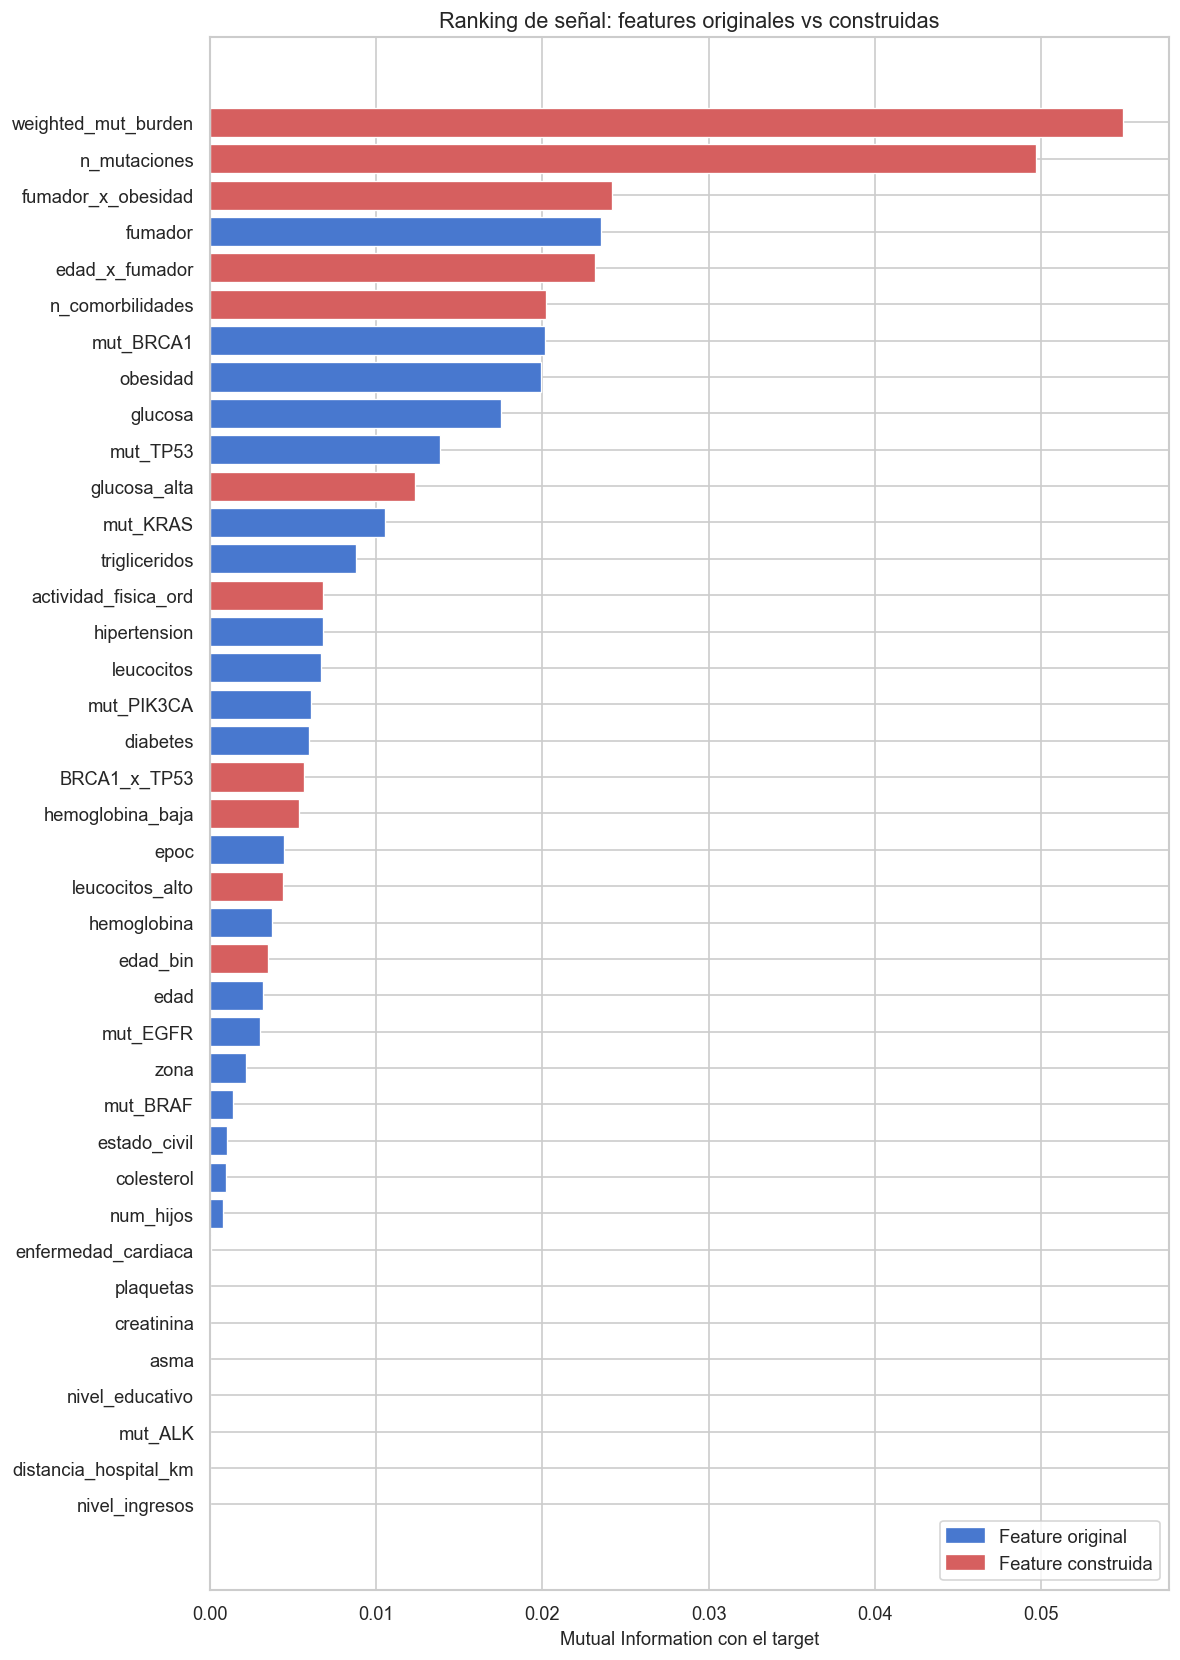

Top 15 features por Mutual Information:
             feature       MI
 weighted_mut_burden 0.054940
        n_mutaciones 0.049695
  fumador_x_obesidad 0.024158
             fumador 0.023527
      edad_x_fumador 0.023165
    n_comorbilidades 0.020210
           mut_BRCA1 0.020130
            obesidad 0.019946
             glucosa 0.017524
            mut_TP53 0.013841
        glucosa_alta 0.012310
            mut_KRAS 0.010507
       trigliceridos 0.008787
actividad_fisica_ord 0.006780
        hipertension 0.006775


In [10]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Preparamos un dataframe con todas las features para mutual information
feature_cols_all = [c for c in df.columns
                    if c not in ['paciente_id', 'cancer', 'actividad_fisica',
                                 'alcohol', 'vive', 'oracle_score'
                                 if 'oracle_score' in df.columns else '__']]

# Encodear categoricas
df_enc = df[feature_cols_all].copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

mi_scores = mutual_info_classif(df_enc.fillna(0), df['cancer'],
                                random_state=42, n_neighbors=5)
df_mi = (pd.DataFrame({'feature': feature_cols_all, 'MI': mi_scores})
           .sort_values('MI', ascending=False)
           .reset_index(drop=True))

# Colorear features construidas vs originales
CONSTRUCTED = {'n_mutaciones','n_comorbilidades','weighted_mut_burden',
               'glucosa_alta','hemoglobina_baja','leucocitos_alto',
               'actividad_fisica_ord','edad_bin',
               'fumador_x_obesidad','BRCA1_x_TP53','edad_x_fumador'}

colors = ['#D65F5F' if f in CONSTRUCTED else '#4878CF'
          for f in df_mi['feature']]

fig, ax = plt.subplots(figsize=(10, 14))
bars = ax.barh(df_mi['feature'][::-1], df_mi['MI'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.8)
ax.set_xlabel('Mutual Information con el target')
ax.set_title('Ranking de señal: features originales vs construidas')

patch_orig = mpatches.Patch(color='#4878CF', label='Feature original')
patch_new  = mpatches.Patch(color='#D65F5F', label='Feature construida')
ax.legend(handles=[patch_orig, patch_new], loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '10_feature_importance_ranking.png'), bbox_inches='tight')
plt.show()

print("Top 15 features por Mutual Information:")
print(df_mi.head(15).to_string(index=False))

---
## Guardado del dataset enriquecido

In [11]:
# Columnas a eliminar del dataset final
DROP_COLS = ['alcohol',   # constante
             'vive',      # leakage temporal
             'mut_ALK',   # chi2=0, sin señal
             'actividad_fisica']  # reemplazada por actividad_fisica_ord

# Eliminar oracle_score si existe (no disponible en produccion)
if 'oracle_score' in df.columns:
    DROP_COLS.append('oracle_score')

df_eng = df.drop(columns=DROP_COLS)

out_path = os.path.join(ROOT, 'data', 'processed', 'df_engineered.parquet')
df_eng.to_parquet(out_path, index=False)

print(f"Dataset maestro:    {df.shape[1]} variables")
print(f"Variables eliminadas: {len(DROP_COLS)} ({DROP_COLS})")
print(f"Dataset enriquecido: {df_eng.shape[1]} variables")
print(f"Guardado en: {out_path}")
print()
print("Features nuevas incluidas:")
for feat, _, _ in NEW_FEATURES:
    print(f"  + {feat}")
print()
print("Listo para Notebook 04 — Preprocesado y Split")

Dataset maestro:    44 variables
Variables eliminadas: 4 (['alcohol', 'vive', 'mut_ALK', 'actividad_fisica'])
Dataset enriquecido: 40 variables
Guardado en: c:\Users\Propietario\Desktop\segundo cuatri\ia\caso cancer\data\processed\df_engineered.parquet

Features nuevas incluidas:
  + n_mutaciones
  + n_comorbilidades
  + weighted_mut_burden
  + glucosa_alta
  + hemoglobina_baja
  + leucocitos_alto
  + actividad_fisica_ord
  + edad_bin
  + fumador_x_obesidad
  + BRCA1_x_TP53
  + edad_x_fumador

Listo para Notebook 04 — Preprocesado y Split
